In [2]:
import numpy as np
import torch
GENO = torch.tensor(
    [
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1],
        [1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1],
    ],
    dtype=torch.long,
)
LEAF_NAMES = ["A", "B", "C", "D"]

# Write .sites file (0→A, 1→G)
with open("example.sites", "w") as f:
    f.write("NAMES\t" + "\t".join(LEAF_NAMES) + "\n")
    f.write("REGION\tchr1\t1\t8\n")
    geno_np = GENO.numpy()
    for site_idx in range(geno_np.shape[1]):
        pos = site_idx + 1  # 1-based
        bases = "".join("A" if g == 0 else "G" for g in geno_np[:, site_idx])
        f.write(f"{pos}\t{bases}\n")

Text(0, 0.5, 'Joint log-probability')

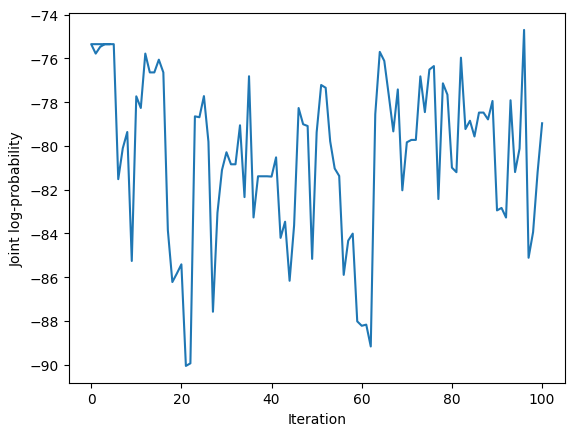

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
stats = pd.read_csv("example_out/out.stats", sep="\t")
stats[["iter", "prior", "likelihood", "joint"]]
plt.plot(stats["iter"], stats["joint"])
plt.xlabel("Iteration"); plt.ylabel("Joint log-probability")